
1.- Realiza una investigación científica sobre el filtro Bayer aplicado en el procesamiento digital de imágenes, el porque se aplica y como proviene; de la misma manera realizando código lista las versiones de filtro Bayer en cv2 y aplícalos en tus imágenes seleccionadas.

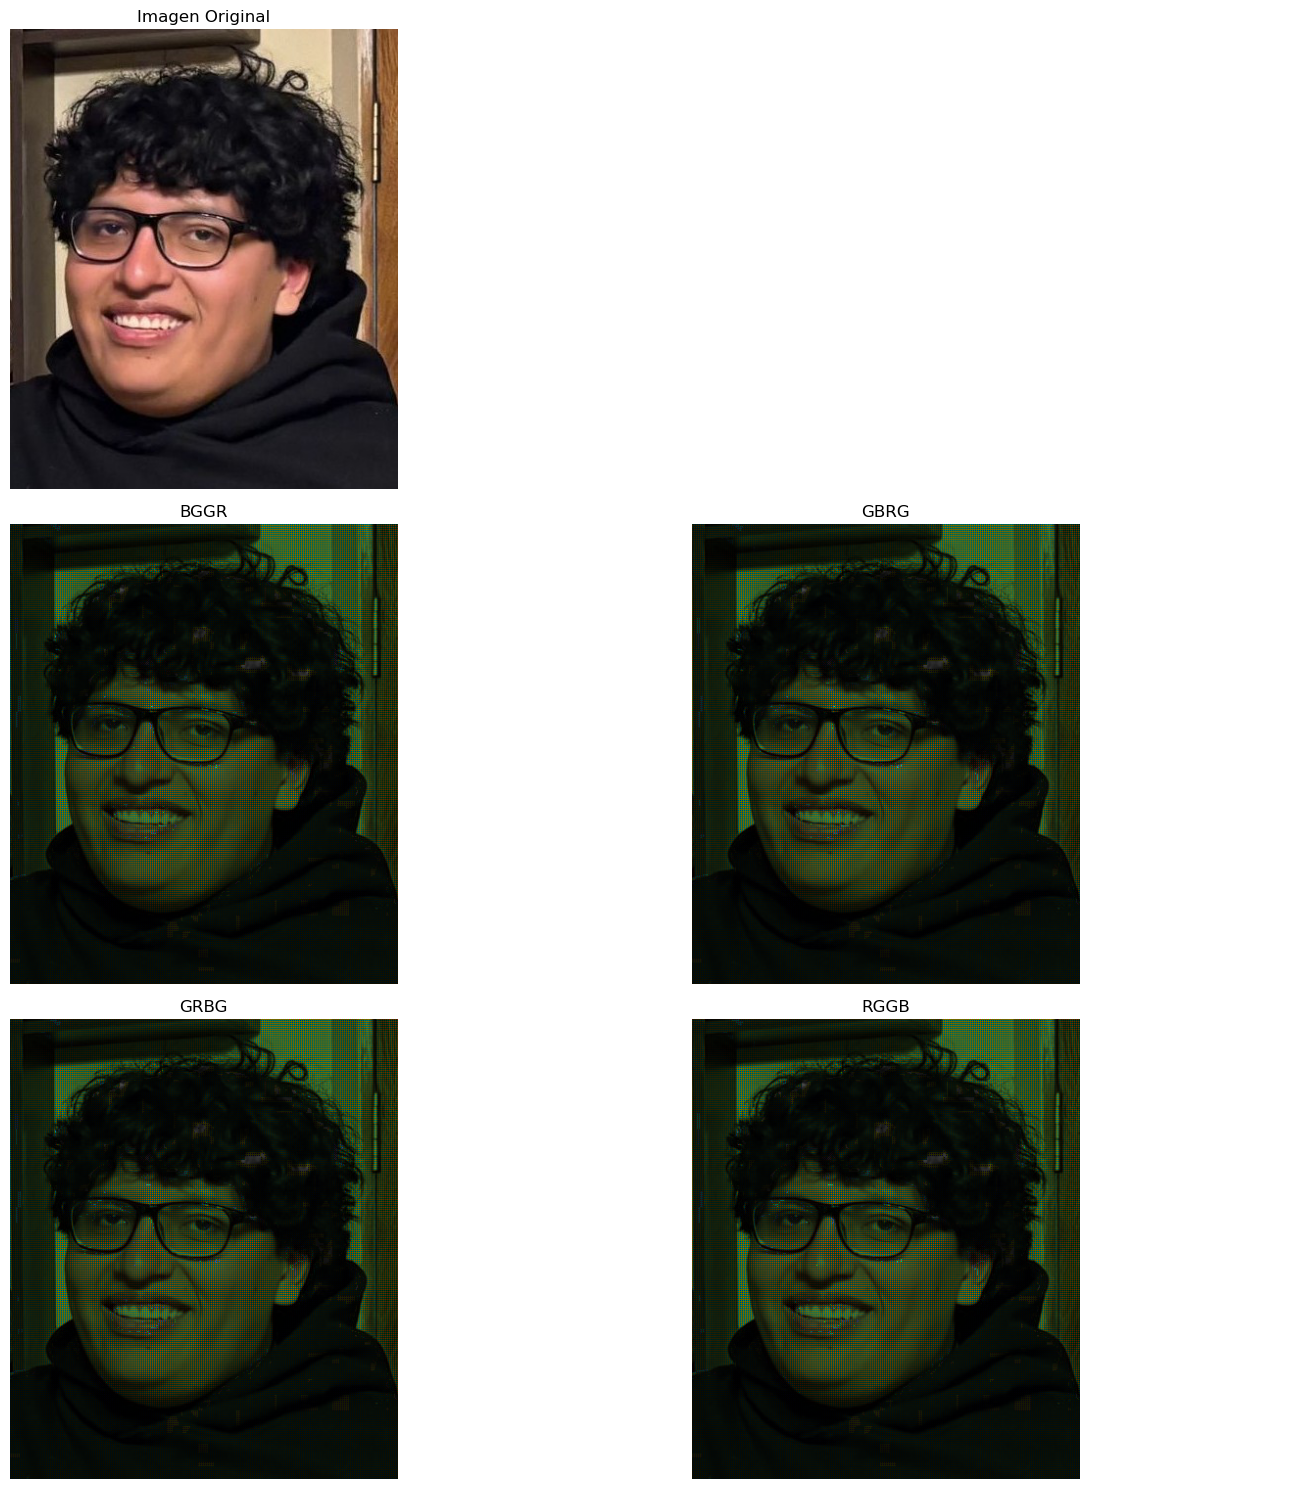

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def cargar_imagen(ruta):
    imagen_bgr = cv2.imread(str(ruta))

    if imagen_bgr is None:
        raise FileNotFoundError("No se pudo cargar la imagen")

    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def separar_canales(imagen):
    rojo = imagen[:, :, 0]
    verde = imagen[:, :, 1]
    azul = imagen[:, :, 2]

    return rojo, verde, azul


def reconstruir_rgb(rojo, verde, azul):
    return np.stack((rojo, verde, azul), axis=2)


def aplicar_patron_bayer(rojo, verde, azul, patron):

    alto, ancho = rojo.shape

    mosaico = np.zeros((alto, ancho), dtype=np.uint8)

    if patron == "BGGR":

        mosaico[0::2, 0::2] = azul[0::2, 0::2]
        mosaico[0::2, 1::2] = verde[0::2, 1::2]
        mosaico[1::2, 0::2] = verde[1::2, 0::2]
        mosaico[1::2, 1::2] = rojo[1::2, 1::2]

    elif patron == "GBRG":

        mosaico[0::2, 0::2] = verde[0::2, 0::2]
        mosaico[0::2, 1::2] = azul[0::2, 1::2]
        mosaico[1::2, 0::2] = rojo[1::2, 0::2]
        mosaico[1::2, 1::2] = verde[1::2, 1::2]

    elif patron == "GRBG":

        mosaico[0::2, 0::2] = verde[0::2, 0::2]
        mosaico[0::2, 1::2] = rojo[0::2, 1::2]
        mosaico[1::2, 0::2] = azul[1::2, 0::2]
        mosaico[1::2, 1::2] = verde[1::2, 1::2]

    elif patron == "RGGB":

        mosaico[0::2, 0::2] = rojo[0::2, 0::2]
        mosaico[0::2, 1::2] = verde[0::2, 1::2]
        mosaico[1::2, 0::2] = verde[1::2, 0::2]
        mosaico[1::2, 1::2] = azul[1::2, 1::2]

    r = np.zeros_like(rojo)
    g = np.zeros_like(verde)
    b = np.zeros_like(azul)

    r[mosaico == rojo] = mosaico[mosaico == rojo]
    g[mosaico == verde] = mosaico[mosaico == verde]
    b[mosaico == azul] = mosaico[mosaico == azul]

    return reconstruir_rgb(r, g, b)

'''
# ANTES
def aplicar_patron_bayer(rojo, verde, azul, patron):

    r = np.zeros_like(rojo)
    g = np.zeros_like(verde)
    b = np.zeros_like(azul)

    if patron == "BGGR":

        b[0::2, 0::2] = azul[0::2, 0::2]
        g[0::2, 1::2] = verde[0::2, 1::2]
        g[1::2, 0::2] = verde[1::2, 0::2]
        r[1::2, 1::2] = rojo[1::2, 1::2]

    elif patron == "GBRG":

        g[0::2, 0::2] = verde[0::2, 0::2]
        b[0::2, 1::2] = azul[0::2, 1::2]
        r[1::2, 0::2] = rojo[1::2, 0::2]
        g[1::2, 1::2] = verde[1::2, 1::2]

    elif patron == "GRBG":

        g[0::2, 0::2] = verde[0::2, 0::2]
        r[0::2, 1::2] = rojo[0::2, 1::2]
        b[1::2, 0::2] = azul[1::2, 0::2]
        g[1::2, 1::2] = verde[1::2, 1::2]

    elif patron == "RGGB":

        r[0::2, 0::2] = rojo[0::2, 0::2]
        g[0::2, 1::2] = verde[0::2, 1::2]
        g[1::2, 0::2] = verde[1::2, 0::2]
        b[1::2, 1::2] = azul[1::2, 1::2]

    return reconstruir_rgb(r, g, b)
'''


def mostrar_resultados(imagen_original, resultados):

    figura, ejes = plt.subplots(3, 2, figsize=(15, 15))

    ejes[0, 0].imshow(imagen_original)
    ejes[0, 0].set_title("Imagen Original")
    ejes[0, 0].axis("off")

    ejes[0, 1].axis("off")

    patrones = list(resultados.keys())

    ejes[1, 0].imshow(resultados[patrones[0]])
    ejes[1, 0].set_title(patrones[0])
    ejes[1, 0].axis("off")

    ejes[1, 1].imshow(resultados[patrones[1]])
    ejes[1, 1].set_title(patrones[1])
    ejes[1, 1].axis("off")

    ejes[2, 0].imshow(resultados[patrones[2]])
    ejes[2, 0].set_title(patrones[2])
    ejes[2, 0].axis("off")

    ejes[2, 1].imshow(resultados[patrones[3]])
    ejes[2, 1].set_title(patrones[3])
    ejes[2, 1].axis("off")

    plt.tight_layout()
    plt.show()


ruta = Path("PDI2026/Clase1/chanki.jpg")

imagen = cargar_imagen(ruta)

rojo, verde, azul = separar_canales(imagen)

patrones = ["BGGR", "GBRG", "GRBG", "RGGB"]

resultados = {}

for patron in patrones:
    resultados[patron] = aplicar_patron_bayer(rojo, verde, azul, patron)

mostrar_resultados(imagen, resultados)

2.- Aplica las las transformaciones de YUV2RGB, RGB2YUV y viceversa a la imagen seleccionada

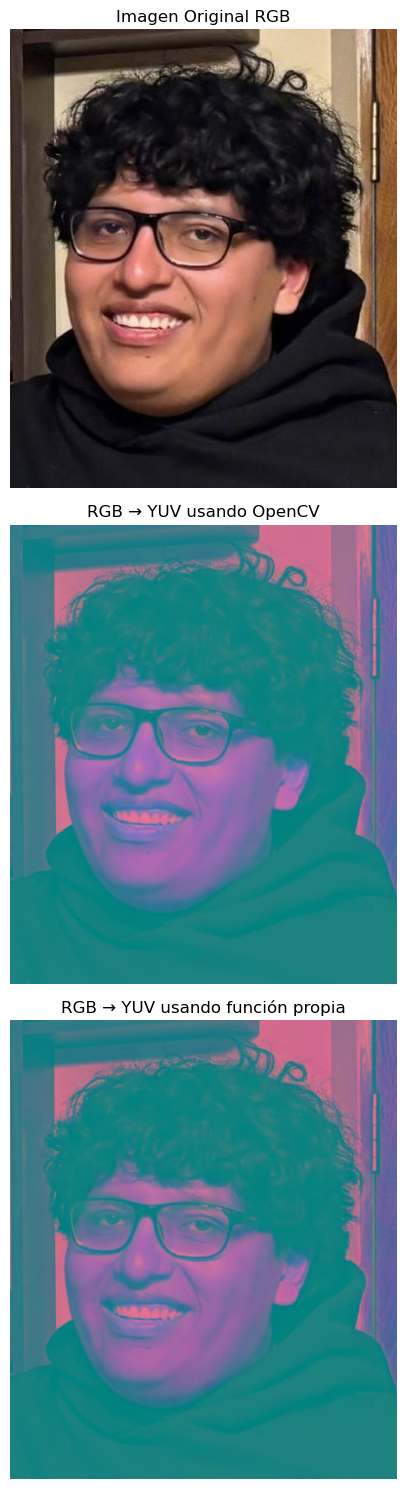

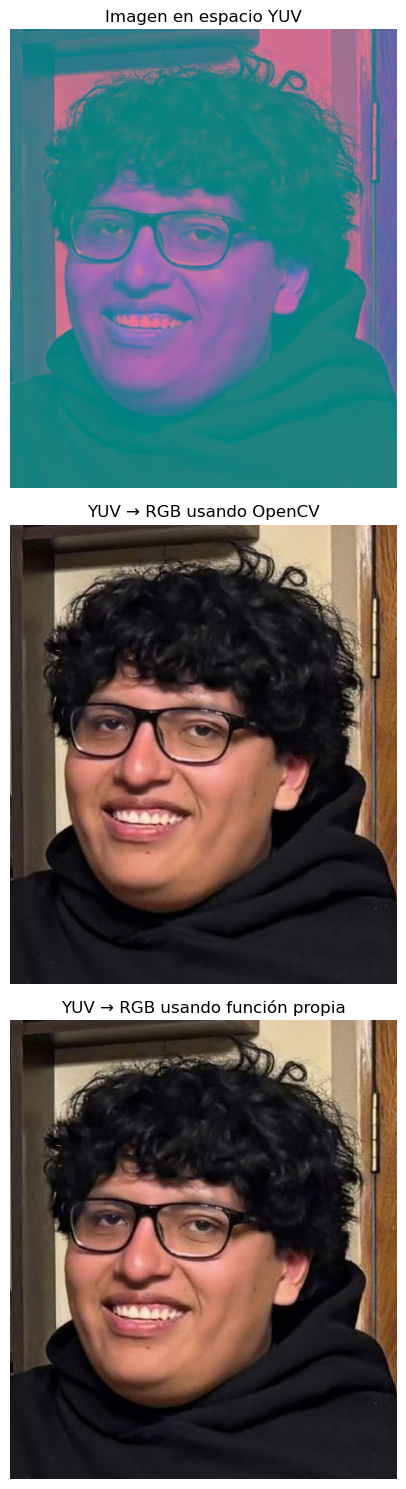

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


def cargar_imagen_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))

    if imagen_bgr is None:
        raise FileNotFoundError("No se pudo cargar la imagen")

    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def RGB2YUV(rgb):

    m = np.array([[0.29900, -0.16874, 0.50000],
                  [0.58700, -0.33126, -0.41869],
                  [0.11400, 0.50000, -0.08131]])

    yuv = np.dot(rgb, m)
    yuv[:, :, 1:] += 128.0

    return yuv


def YUV2RGB(yuv):

    m = np.array([[1.0, 1.0, 1.0],
                  [-0.000007154783816076815, -0.3441331386566162, 1.7720025777816772],
                  [1.4019975662231445, -0.7141380310058594, 0.00001542569043522235]])

    rgb = np.dot(yuv, m)

    rgb[:, :, 0] -= 179.45477266423404
    rgb[:, :, 1] += 135.45870971679688
    rgb[:, :, 2] -= 226.8183044444304

    return rgb


def mostrar_transformaciones_yuv(imagen_rgb):

    imagen_yuv_cv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2YUV)

    imagen_yuv_manual = RGB2YUV(imagen_rgb)

    imagen_rgb_cv = cv2.cvtColor(imagen_yuv_cv, cv2.COLOR_YUV2RGB)

    imagen_rgb_manual = YUV2RGB(imagen_yuv_manual)

    imagen_yuv_manual = np.clip(imagen_yuv_manual, 0, 255).astype(np.uint8)
    imagen_rgb_manual = np.clip(imagen_rgb_manual, 0, 255).astype(np.uint8)

    figura1, ejes1 = plt.subplots(3, 1, figsize=(15, 15))

    ejes1[0].imshow(imagen_rgb)
    ejes1[0].set_title("Imagen Original RGB")
    ejes1[0].axis("off")

    ejes1[1].imshow(imagen_yuv_cv)
    ejes1[1].set_title("RGB → YUV usando OpenCV")
    ejes1[1].axis("off")

    ejes1[2].imshow(imagen_yuv_manual)
    ejes1[2].set_title("RGB → YUV usando función propia")
    ejes1[2].axis("off")

    plt.tight_layout()
    plt.show()

    figura2, ejes2 = plt.subplots(3, 1, figsize=(15, 15))

    ejes2[0].imshow(imagen_yuv_cv)
    ejes2[0].set_title("Imagen en espacio YUV")
    ejes2[0].axis("off")

    ejes2[1].imshow(imagen_rgb_cv)
    ejes2[1].set_title("YUV → RGB usando OpenCV")
    ejes2[1].axis("off")

    ejes2[2].imshow(imagen_rgb_manual)
    ejes2[2].set_title("YUV → RGB usando función propia")
    ejes2[2].axis("off")

    plt.tight_layout()
    plt.show()


ruta_imagen = Path("PDI2026/Clase1/chanki.jpg")

imagen_rgb = cargar_imagen_rgb(ruta_imagen)

mostrar_transformaciones_yuv(imagen_rgb)